## Componentes

- ***Tendencia***        : ingremento o reducción de los valores de la serie de tiempo a largo plazo
- ***Estacionalidad***   : patrón de maximos y minimos que se repite periódicamente
- ***Ruido***            : patrones de la estructura temporal que no son captados por la tendencia ni la estacionalidad

- ***Ciclos***            : máximos y minimos que aparecen 

### Primer paso:

Definir si el tipo de modelo es:

<p align="center">
<strong>Aditivo</strong>:  Y(t) = T(t) + S(t) + R(t) 
</p>

<p align="center">
<strong>Multiplicativo</strong>: Y(t) = T(t) * S(t) * R(t) 
</p>

Se debe de elegir el modelo que arroje los valores de ruido R(t) menores, así que se tienen que averiguar todos los modelos posibles para eligir la mejor opción

### Desomposición con ***Statsmodels***

In [2]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [3]:
co2 = pd.read_csv('datos/co2.csv',
                parse_dates=['fecha'],
                index_col='fecha')
co2

,co2
fecha,
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2


<Axes: xlabel='fecha'>

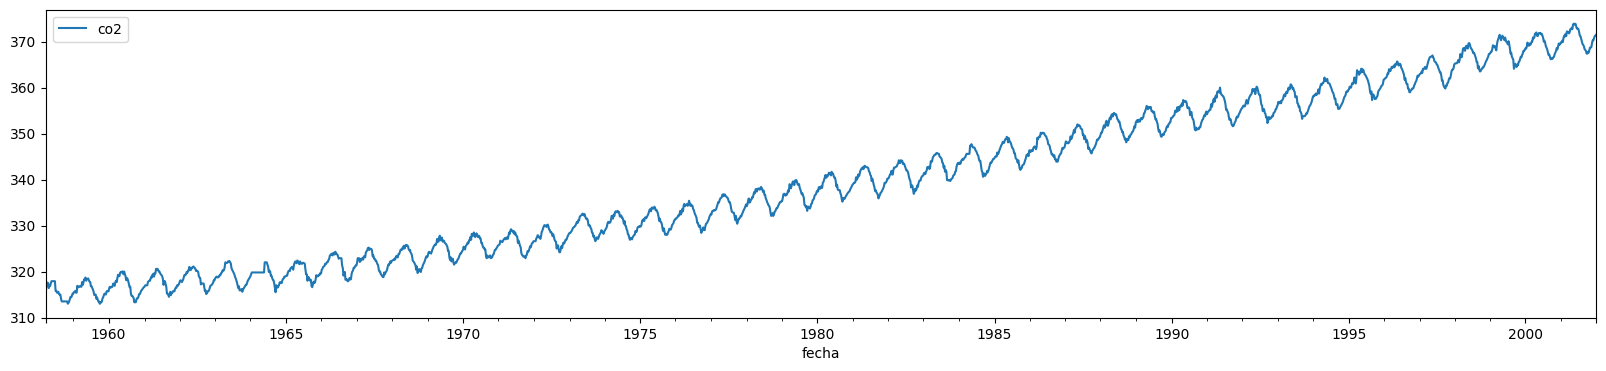

In [4]:
co2.plot(figsize=(20,4))

In [5]:
co2.index
# Frecuencia de semanas

DatetimeIndex(['1958-03-29', '1958-04-05', '1958-04-12', '1958-04-19',
               '1958-04-26', '1958-05-03', '1958-05-10', '1958-05-17',
               '1958-05-24', '1958-05-31',
               ...
               '2001-10-27', '2001-11-03', '2001-11-10', '2001-11-17',
               '2001-11-24', '2001-12-01', '2001-12-08', '2001-12-15',
               '2001-12-22', '2001-12-29'],
              dtype='datetime64[us]', name='fecha', length=2284, freq=None)

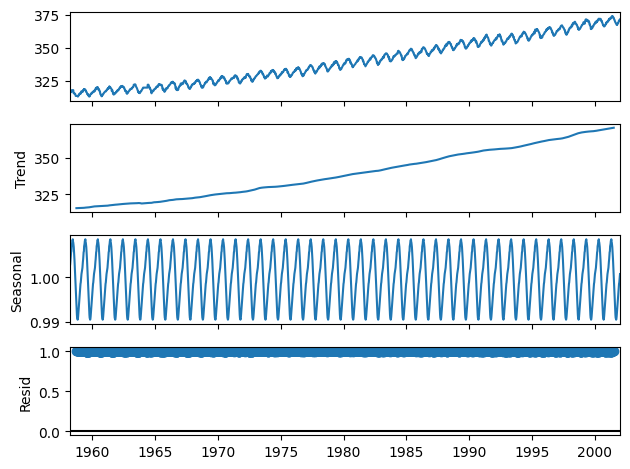

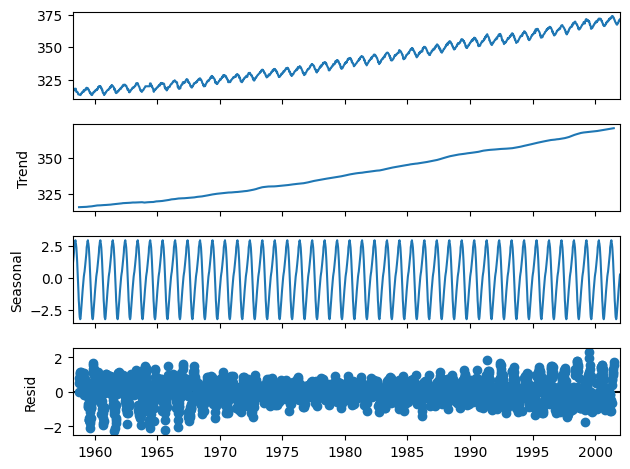

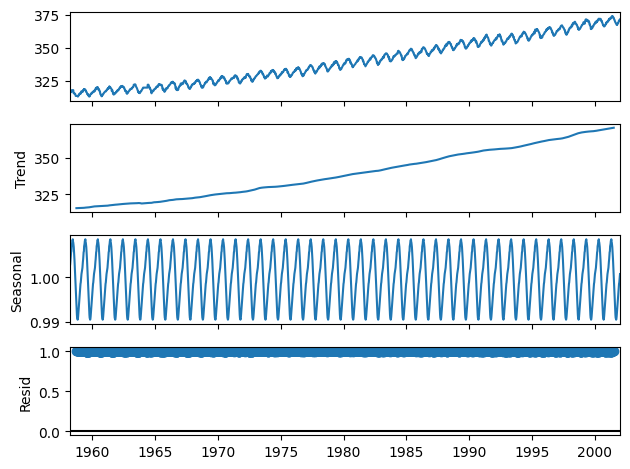

In [6]:
co2_dec_add = seasonal_decompose(co2, model='additive')
co2_dec_mult = seasonal_decompose(co2, model='mult')

co2_dec_add.plot()
co2_dec_mult.plot()

In [7]:
pasajeros = pd.read_csv('datos/pasajeros.csv',
                parse_dates=['fecha'],
                index_col='fecha')
pasajeros

,nro
fecha,
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121
...,...
1960-08-31,606
1960-09-30,508
1960-10-31,461


<Axes: xlabel='fecha'>

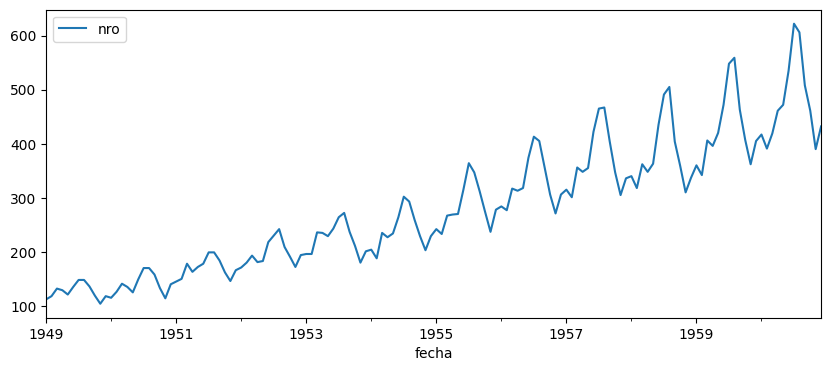

In [8]:
pasajeros.plot(figsize=(10,4))

In [9]:
pasajeros.index
# Frecuencia mensual

DatetimeIndex(['1949-01-31', '1949-02-28', '1949-03-31', '1949-04-30',
               '1949-05-31', '1949-06-30', '1949-07-31', '1949-08-31',
               '1949-09-30', '1949-10-31',
               ...
               '1960-03-31', '1960-04-30', '1960-05-31', '1960-06-30',
               '1960-07-31', '1960-08-31', '1960-09-30', '1960-10-31',
               '1960-11-30', '1960-12-31'],
              dtype='datetime64[us]', name='fecha', length=144, freq=None)

In [10]:
pasajeros_dec_add = seasonal_decompose(pasajeros, model='additive')
pasajeros_dec_mult = seasonal_decompose(pasajeros, model = 'mult')

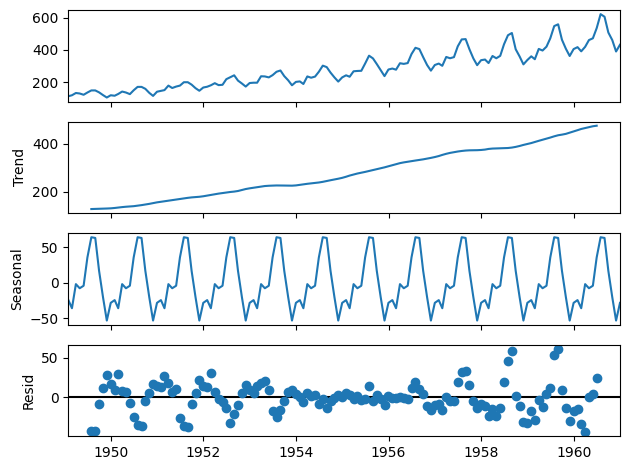

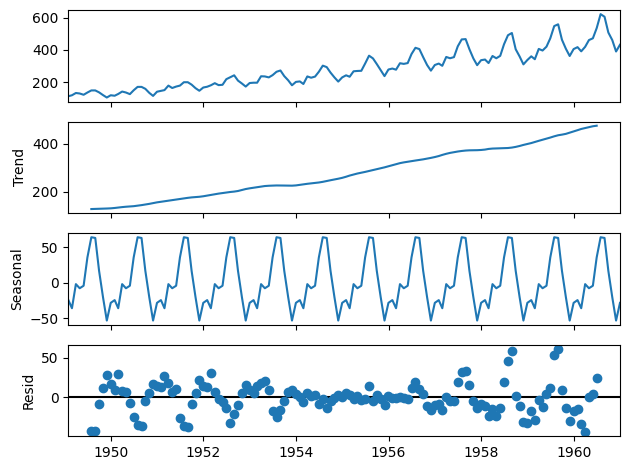

In [11]:
pasajeros_dec_add.plot()

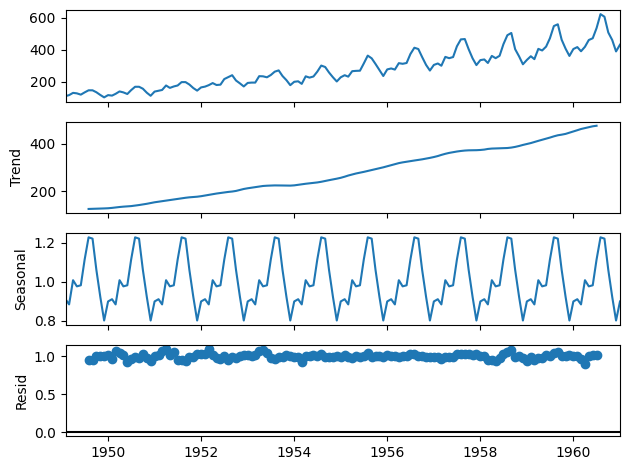

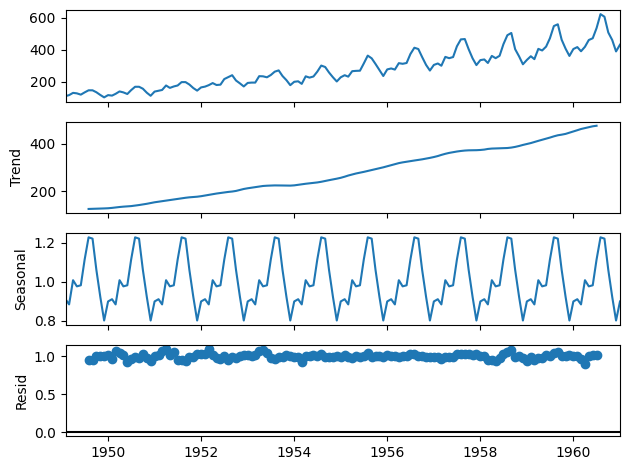

In [12]:
pasajeros_dec_mult.plot()

### Desomposición con ***STL***
Seasonal and Trend decomposition using Loess
- Se asume un modelo aditivo
- Se asume una periodicidad para la descomposición, debe ser un valor impar superior próximo al valor de periodicidad estimamda

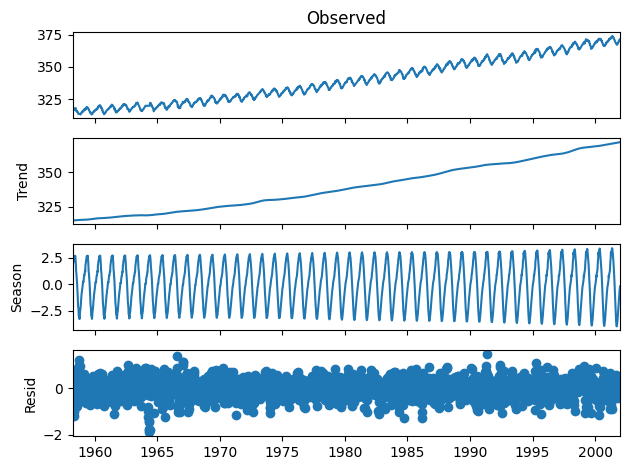

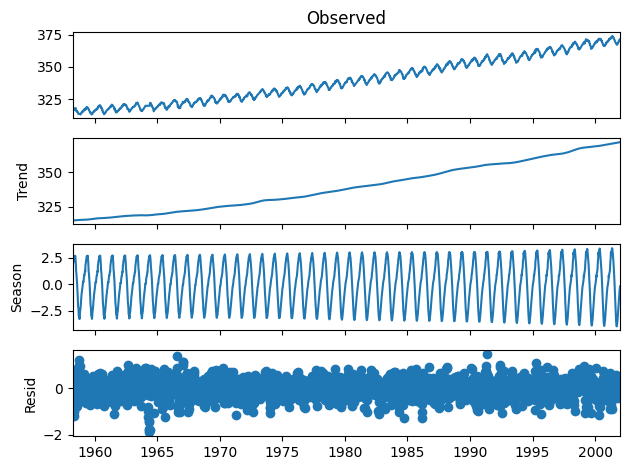

In [13]:
from statsmodels.tsa.seasonal import STL

co2_stl = STL(co2,
            seasonal = 53).fit()
co2_stl.plot()

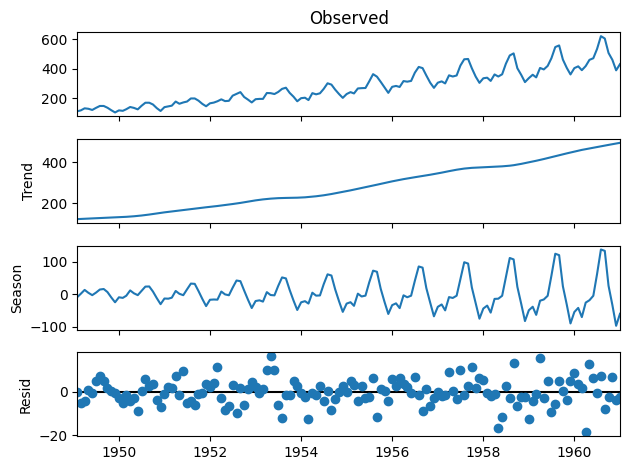

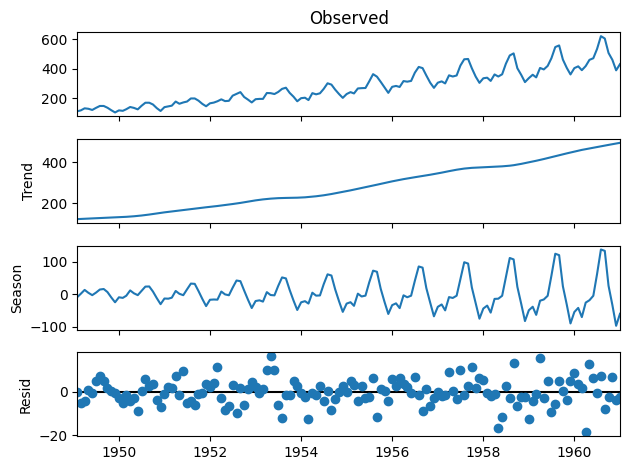

In [14]:
pasajeros_stl = STL(pasajeros, seasonal = 13).fit()
pasajeros_stl.plot()

### Comparación de los residuos

Para serie de CO2

In [15]:
print(f"Modelo aditivo       : {co2_dec_add.resid.mean():.4f}")
print(f"Modelo multiplicativo: {co2_dec_mult.resid.mean():.4f}")
print(f"Modelo STL           : {co2_stl.resid.mean():.4f}")

Modelo aditivo       : 0.0039
Modelo multiplicativo: 1.0000
Modelo STL           : -0.0010


Para serie de Pasajeros

In [16]:
print(f"Modelo aditivo       : {pasajeros_dec_add.resid.mean():.4f}")
print(f"Modelo multiplicativo: {pasajeros_dec_mult.resid.mean():.4f}")
print(f"Modelo STL           : {pasajeros_stl.resid.mean():.4f}")

Modelo aditivo       : -0.7513
Modelo multiplicativo: 0.9982
Modelo STL           : -0.1212
